### Adaptive RAG
Adaptive Retrieval-Augmented Generation is a retrieval system where the amount, type, and strategy of retrieval changes dynamically based on the AI agent’s reasoning needs—rather than being fixed (as in classic RAG).

In short:
Instead of retrieving once, the model repeatedly decides what to retrieve, when, and whether to retrieve at all.

This makes RAG behave more like an autonomous reasoning loop rather than a single retrieval call.

Dynamic Knowledge Acquisition:
The model chooses how to get information:
Vector search
Web search
DB queries
File lookups
API calls

Self-reflection & correction
The agent inspects its own reasoning:
“Do I have enough info?”
“Is the retrieved info relevant?”
“Do I need to search again with a different query?”

![alt text](Plan.png)

Above diagram -> Adaptive rag -combo of query analysis and Rag +self reflection and below diagram is logic

![Adaptive RAG Flowchart](Screenshot%20%2830%29.png)

In [129]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [130]:
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY']=os.getenv('LANGSMITH_API_KEY')
os.environ['OPENAI_API_KEY']=os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_PROJECT']='Agent_React'



In [131]:
import nest_asyncio
nest_asyncio.apply()

In [132]:
from langchain_community.document_loaders import PlaywrightURLLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [133]:
# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

In [134]:
async def load_docs(urls):
    """
    Load multiple web pages asynchronously using PlaywrightURLLoader.

    Args:
        urls (list): List of URLs to load.

    Returns:
        list: List of Langchain Document objects.
    """
    loader = PlaywrightURLLoader(urls=urls)
    docs =await loader.aload()
    return docs

    

In [135]:
docs =await load_docs(urls)
print(len(docs))
print(docs[1].page_content)

3
Prompt Engineering

Date: March 15, 2023 | Estimated Reading Time: 21 min | Author: Lilian Weng

Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.

This post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.

[My personal spicy take] In my opinion, some prompt engineering papers are not worthy 8 pages long, since those tricks can be explained in one or a few sentences and the rest is all about benchmarking. An easy-to-use and shared benchmark infrastructure should be mo

In [136]:
text_splitter =RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,chunk_overlap=50
)

docs_splits =text_splitter.split_documents(documents=docs)

vector_store =FAISS.from_documents(documents=docs_splits,embedding=OpenAIEmbeddings())

retriever =vector_store.as_retriever()

In [137]:
retriever.invoke('what is short term memory?')

[Document(id='ea25f2f8-2daa-42d4-92a7-dae4dfcf3641', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='In comparison with three baselines, including ED (expert distillation, behavior cloning with expert trajectories instead of learning history), source policy (used for generating trajectories for distillation by UCB), RL^2 (Duan et al. 2017; used as upper bound since it needs online RL), AD demonstrates in-context RL with performance getting close to RL^2 despite only using offline RL and learns much faster than other baselines. When conditioned on partial training history of the source policy, AD also improves much faster than ED baseline.\n\nComponent Two: Memory#\n\n(Big thank you to ChatGPT for helping me draft this section. I’ve learned a lot about the human brain and data structure for fast MIPS in my conversations with ChatGPT.)\n\nTypes of Memory#\n\nMemory can be defined as the processes used to acquire, store, retain, and later retriev

In [138]:
from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

In [139]:
#Question Router
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource:Literal['web_search','vectorstore']=Field(description=
    "Given a user question choose to route it to web search or a vectorstore.")

#Structured Output ,Schema-enforced generation
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""

router_prompt =ChatPromptTemplate.from_messages(
    [
    ('system',system),  # system message
    ('human','{question}') # human message with placeholder
    ]

)

question_router =router_prompt|structured_llm_router



In [140]:
print(
    question_router.invoke(
        {"question": "Who will be next pm of uk? "}
    )
)
print(
    question_router.invoke(
        {"question": "what is long term memory in agents? "}
    )
)

datasource='web_search'
datasource='vectorstore'


In [141]:
# Document Grader

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str =Field(description="Documents are relevant to the question, 'yes' or 'no'")

structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grader_prompt =ChatPromptTemplate.from_messages(
    [
        ('system',system),
        ('human','Retreived Document:{document}\n\n User question:{question}\n\n')
    ]
)

retrieval_grader =grader_prompt|structured_llm_grader

question ='agent memory'
docs = retriever.invoke(question)
docs_text =docs[0].page_content
print(retrieval_grader.invoke({"document":docs_text,"question":question}))


binary_score='yes'


In [142]:
# Loop through each document
for i, doc in enumerate(docs):
    doc_text = doc.page_content
    
    # Invoke the structured grader
    result = retrieval_grader.invoke({
        "document": doc_text,
        "question": question
    })
    
    # Print the result
    print(f"Document {i+1} relevance score:", result.binary_score)

Document 1 relevance score: yes
Document 2 relevance score: yes
Document 3 relevance score: yes
Document 4 relevance score: yes


In [143]:
#Generate 
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
client =Client()
rag_prompt = client.pull_prompt("rlm/rag-prompt")



In [144]:
generate_rag_chain =rag_prompt|llm|StrOutputParser()

generation =generate_rag_chain.invoke({"question":question,"context":docs})
print(generation)

Agent memory refers to the mechanisms that allow generative agents to retain and utilize past experiences to inform their behavior. It includes long-term memory, which records comprehensive experiences, and short-term memory, which involves in-context learning. This memory system enables agents to reflect on past actions and plan future behaviors effectively.


In [145]:
#hallucination Grader
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )
structured_llm_hallucination_grader =llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',system),
        ('set of facts:\n\n{documents} generation:{generation}')
    ]
)

hallucination_grader = hallucination_prompt|structured_llm_grader

hallucination_grader.invoke({"documents":docs,"generation":generation})

GradeDocuments(binary_score='yes')

In [146]:
### Answer Grader

# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [147]:
#Question rewriter
# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""

question_rewriter_prompt =ChatPromptTemplate.from_messages(
    [
        ("system",system),
        (f'here is the initial question:{question}\n\n formulate an improved question.')
    ]
)

question_rewriter =question_rewriter_prompt|llm|StrOutputParser()

question_rewriter.invoke({"question":question})

'What is the concept of agent memory in artificial intelligence, and how does it impact decision-making processes?'

In [148]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool =TavilySearchResults()

In [149]:
from typing import List,TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """
    
    question:str
    generation:str
    documents:List[str]

In [150]:
from langchain_core.documents import Document

In [151]:
def retrieve(state:GraphState):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")

    question=state['question']
    documents =retriever.invoke(question)
    return {"documents":documents,"question":question}



In [152]:
def generate(state:GraphState):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question=state['question']
    documents =state['documents']

    generation =generate_rag_chain.invoke({"question":question,"context":documents})
    return {"question":question,"documents":documents,"generation":generation}


In [153]:
def grade_documents(state:GraphState):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question =state['question']
    documents =state['documents']

    filtered_docs =[]
    for d in documents:
        score =retrieval_grader.invoke({"document":d.page_content,"question":question})
        grade =score.binary_score
        if grade =='yes':
            filtered_docs.append(d)
            print("---GRADE: DOCUMENT RELEVANT---")
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents":filtered_docs,"question":question}


In [154]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    better_question =question_rewriter.invoke({"question":question})
    return {"documents":documents,"question":better_question}
    

In [155]:
def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    #web search
    docs =web_search_tool.invoke({"query":question})
    web_results ="\n\n".join([d['content']  for d in docs])
    web_results=Document(page_content=web_results)
    
    return {"question":question,"documents":web_results}

In [156]:
def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source =question_router.invoke({"question":question})
    
    if source.datasource=="web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource=="vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"

In [157]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        print(
            "---DECISION: NO DOCUMENTS ARE RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return 'transform_query'
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return 'generate'

In [158]:
def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [159]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

workflow.add_conditional_edges(START,
route_question,
{'web_search':'web_search',
 'vectorstore':'retrieve'})

workflow.add_edge('web_search','generate')

workflow.add_edge('retrieve','grade_documents')
workflow.add_conditional_edges('grade_documents',
decide_to_generate,
{'transform_query':'transform_query',
"generate":"generate"})

workflow.add_edge('transform_query','retrieve')

workflow.add_conditional_edges('generate',
grade_generation_v_documents_and_question,
{'useful':END,
'not useful':'transform_query',
'not supported':'generate'})

# Compile
app = workflow.compile()

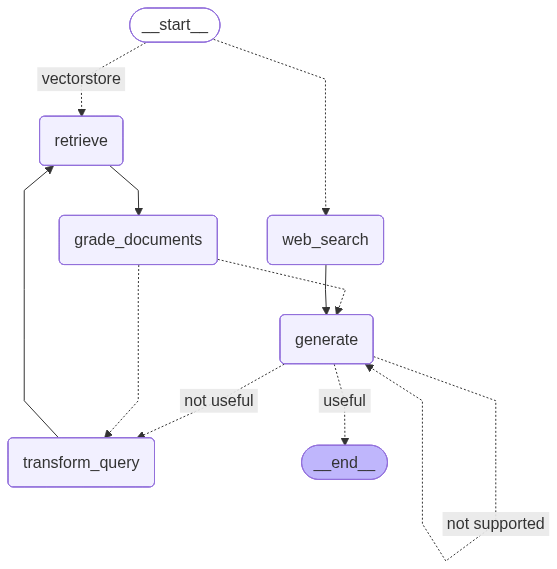

In [160]:
from IPython.display import Image,display

display(Image(app.get_graph().draw_mermaid_png()))



In [161]:
app.invoke({"question":"What is machine learning"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is machine learning',
 'generation': 'Machine learning is a subset of artificial intelligence that focuses on algorithms capable of learning patterns from training data to make predictions or decisions without explicit programming. It enables systems to analyze data, recognize patterns, and improve their performance over time. Common applications include image classification, fraud detection, and predictive analytics.',
 'documents': Document(metadata={}, page_content='# What is machine learning?\n\n## Author\n\nDave Bergmann \n\nSenior Staff Writer, AI Models\n\nIBM Think\n\n## What is machine learning?\n\nMachine learning is the subset of artificial intelligence (AI) focused on algorithms that can “learn” the patterns of training data and, subsequently, make accurate inferences about new data. This pattern recognition ability enables machine learning models to make decisions or predictions without explicit, hard-coded instructions.\n\nMachine learning has come to d

In [162]:
app.invoke({"question":"What is long term memory and short term memory in agents how they differ and when to use it  ?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is long term memory and short term memory in agents how they differ and when to use it  ?',
 'generation': 'Short-term memory (STM) in agents refers to in-context learning, which is limited by the finite context window of the model, allowing it to retain information temporarily for immediate tasks. Long-term memory (LTM), on the other hand, enables agents to store and retrieve information over extended periods, often using an external vector store for fast access. Use STM for immediate, short-term tasks and LTM for retaining knowledge that can be recalled for future use.',
 'documents': [Document(id='ea25f2f8-2daa-42d4-92a7-dae4dfcf3641', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='In comparison with three baselines, including ED (expert distillation, behavior cloning with expert trajectories instead of learning history), source policy (used for generating trajectories for distillation by UCB), RL^2 (Duan et al. 2017; us

In [163]:
"""
Adaptive RAG Pipeline – This code explaination

1️⃣ Step 1 — Route Question
   - LLM router decides which path to take:
       class RouteQuery(BaseModel):
           datasource: Literal['web_search','vectorstore']
   - Output is either "vectorstore" or "web_search".
   - Decision gate for the next step.

2️⃣ Step 2 — Transform Query (vectorstore path only)
   - Rewrites the question for better retrieval.
   - Removes noise and clarifies intent.
   - Improves vectorstore retrieval accuracy.

3️⃣ Step 3 — Retrieve Documents
   - Fetch documents from FAISS using the transformed query:
       docs = retriever.invoke(question)
   - Vectorstore retrieval is fast and reliable.

4️⃣ Step 4 — Grade Retrieved Documents
   - LLM grader checks each document’s relevance:
       class GradeDocuments(BaseModel):
           binary_score: Literal["yes","no"]
   - Keep relevant docs, drop irrelevant ones.
   - Example:
       Doc  d1 → ❌ no → dropped
       Doc  d2 → ✔️ yes → kept
       Doc  d3 → ✔️ yes → kept
   - Improves answer accuracy.

5️⃣ Step 5 — Generate Answer
   - Send filtered documents + question to the LLM.
   - LLM produces a candidate answer.

6️⃣ Step 6 — Grade Hallucination
   - Check if the answer is grounded in retrieved documents.
   - Example:
       Docs say: “agent memory stores structured data”
       Answer says: “agent memory invented in 2023” → hallucinating
   - Ensures answers are factually supported.

7️⃣ Step 7 — Grade Answer vs Question
   - Check if answer actually resolves the user question.
   - Example:
       Question: “What is agent memory?”
       Answer: “LangChain uses embeddings.” → factual but not answering → Not useful

8️⃣ Step 8 — Workflow Decisions
   - If grounded + answers question → final output
   - If hallucination → retry generation
   - If irrelevant docs → retry retrieval
   - If still useless → route to web search
   - Creates an agentic, self-correcting RAG system.
"""

'\nAdaptive RAG Pipeline – This code explaination\n\n1️⃣ Step 1 — Route Question\n   - LLM router decides which path to take:\n       class RouteQuery(BaseModel):\n           datasource: Literal[\'web_search\',\'vectorstore\']\n   - Output is either "vectorstore" or "web_search".\n   - Decision gate for the next step.\n\n2️⃣ Step 2 — Transform Query (vectorstore path only)\n   - Rewrites the question for better retrieval.\n   - Removes noise and clarifies intent.\n   - Improves vectorstore retrieval accuracy.\n\n3️⃣ Step 3 — Retrieve Documents\n   - Fetch documents from FAISS using the transformed query:\n       docs = retriever.invoke(question)\n   - Vectorstore retrieval is fast and reliable.\n\n4️⃣ Step 4 — Grade Retrieved Documents\n   - LLM grader checks each document’s relevance:\n       class GradeDocuments(BaseModel):\n           binary_score: Literal["yes","no"]\n   - Keep relevant docs, drop irrelevant ones.\n   - Example:\n       Doc  d1 → ❌ no → dropped\n       Doc  d2 → ✔️

#### Cant Trust Much with Grader Yes or No So to further improvise 

1️⃣ Use Multiple Graders or Ensemble
Instead of relying on one LLM, use 2–3 different models to grade the same document or answer.
Take a majority vote: if 2 out of 3 say “yes,” accept it.

Pros: more robust
Cons: higher cost, slower

2️⃣ Use Scoring Instead of Strict Yes/No
Instead of binary output, ask the grader to give a confidence score: 0–1 or 0–100%.

Example:
class GradeDocuments(BaseModel):
    relevance_score: float = Field(..., description="0–1 relevance score")

Then set a threshold (e.g., 0.7) rather than blindly trusting “yes.”
Pros: smoother decision-making, less brittle
Cons: needs threshold tuning

3️⃣ Combine LLM Grading with Rule-Based Checks
Use keywords, semantic similarity, or embeddings to double-check:
If cosine_similarity(document_embedding, question_embedding) > 0.75, accept automatically

Otherwise, fallback to LLM grading
Pros: more deterministic
Cons: may miss nuanced relevance that only LLM understands

4️⃣ Use Retrieval Confidence / Relevance Score from Vectorstore
Many vector stores (FAISS, Pinecone, Chroma) return a similarity score when retrieving docs.
Filter by similarity first, then only use LLM grading for borderline cases.

Pros: cheap and fast pre-filtering
Cons: raw similarity doesn’t understand semantic nuances

5️⃣ Human-in-the-Loop (HITL)

For critical applications, let humans review LLM judgments, especially for:
Hallucination detection
Sensitive or high-stakes questions
Pros: most reliable
Cons: slower, manual effort